<a href="https://colab.research.google.com/github/umamanasir/MachineLearning-Projects/blob/main/SpamDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email Spam Classification

The goal of this system is to classify emails as "spam" or "nospam"

Dataset is taken from Kaggle: [Here is the location](https://www.kaggle.com/datasets/venky73/spam-mails-dataset/data)

Data Cleaning:
1. Remove unnecessary columns
2. Rename columns for clarity
3. Remove duplicates.
4. Check for null values

Exploratory Data Analysis:
1. Total Ham vs Spam
2. Avg length of emails for spam vs ham
3. Avg words for emails of spam vs ham
4. Word Cloud for Spam vs Ham

Data Pre-processing:
1. Lower-case: the characters of the email are made lower-case
2. Regex: is used to remove special characters and white-spaces.  
3. Stopwords: stopwords for eng langage were removed.
4. Stemming using nltk.PorterStem

Machine Learning:
1. A TF-IDF vectorizer was used to convert features (email contents) and target (0 or 1).
2. An 80/20 split was done for Test/Train data
3. Naive Bayes algorithm was used for the model training.

Finally, the model's performance is evaluated using methods like:
1.  Confusion Matrix
2. Accuracy: 94% accuracy was reported
3. Classification Report: F1 score, precision and recall were noted.

In [97]:
import numpy as np

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "spam_ham_dataset.csv"

# Load the latest version
dataset = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "venky73/spam-mails-dataset",
  file_path,
)

/tmp/ipykernel_855/862987727.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dataset = kagglehub.load_dataset(


100%|██████████| 1.86M/1.86M [00:00<00:00, 92.5MB/s]

Extracting zip of spam_ham_dataset.csv...


In [36]:
df = dataset #this is done purely so kaggle wont have to reload again and again if changes are made to the dataset in one session.

In [37]:
df.head()

,emails,result
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [38]:
df.tail()

,emails,result
5166,Subject: put the 10 on the ft\r\nthe transport...,0
5167,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,Subject: industrial worksheets for august 2000...,0
5170,Subject: important online banking alert\r\ndea...,1


In [39]:
df.shape

(5171, 2)

## Data Cleaning

In [40]:
df.drop(columns=['Unnamed: 0', 'label'], inplace=True) #drop extra columns

df.rename(columns={'text': 'emails', 'label_num': 'result'}, inplace=True) #rename

KeyError: "['Unnamed: 0', 'label'] not found in axis"

In [41]:
df.isnull().sum() #check for null values

,0
emails,0
result,0


In [42]:
df.duplicated().sum() #check for duplicates

np.int64(178)

In [43]:
df = df.drop_duplicates(keep='first') #drop duplicates.
df.shape

(4993, 2)

In [44]:
df.dtypes #check datatypes of the colums

,0
emails,object
result,int64


In [45]:
df['emails'] = df['emails'].str.lower()

/tmp/ipykernel_855/2906688790.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emails'] = df['emails'].str.lower()


In [46]:
df.head()

,emails,result
0,subject: enron methanol ; meter # : 988291\r\n...,0
1,"subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"subject: photoshop , windows , office . cheap ...",1
4,subject: re : indian springs\r\nthis deal is t...,0


In [47]:
# using regex to remove special characters
import re
pattern = r'[^\w\s]' #remove special characters.

df['emails'] = df['emails'].str.replace(pattern, '',regex=True)


/tmp/ipykernel_855/756767942.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emails'] = df['emails'].str.replace(pattern, '',regex=True)


In [48]:
df.head()

,emails,result
0,subject enron methanol meter 988291\r\nthis...,0
1,subject hpl nom for january 9 2001\r\n see at...,0
2,subject neon retreat\r\nho ho ho we re aroun...,0
3,subject photoshop windows office cheap mai...,1
4,subject re indian springs\r\nthis deal is to ...,0


## Exploratory Data Analysis

In [49]:
import matplotlib.pyplot as plt


In [50]:
ham = (df['result']==0).sum() #num of ham entries
spam =  (df['result']==1).sum() #num of spam entries.

Ham:  3531 
Spam:  1462


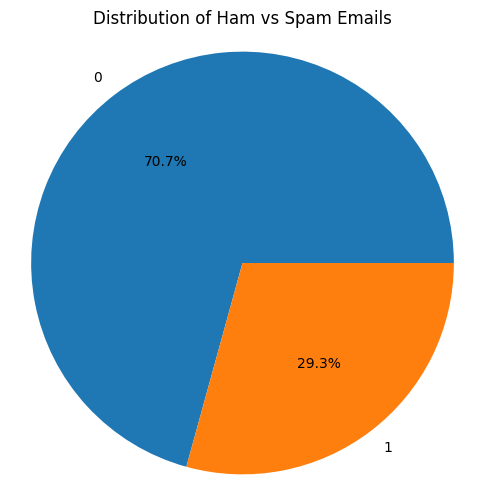

In [51]:
plt.figure(figsize=(6,6))
plt.pie(
    df['result'].value_counts(),
    labels =df['result'].value_counts().index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Ham vs Spam Emails")
plt.axis('equal')
print("Ham: ", ham, "\nSpam: ", spam)
plt.show()

In [52]:
df['length']= df['emails'].str.len()
df.head()

/tmp/ipykernel_855/2628253556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length']= df['emails'].str.len()


,emails,result,length
0,subject enron methanol meter 988291\r\nthis...,0,312
1,subject hpl nom for january 9 2001\r\n see at...,0,89
2,subject neon retreat\r\nho ho ho we re aroun...,0,2442
3,subject photoshop windows office cheap mai...,1,409
4,subject re indian springs\r\nthis deal is to ...,0,329


In [53]:
avg_spam = df[df['result'] == 1]['length'].mean()
avg_ham = df[df['result'] == 0]['length'].mean()

print(avg_spam, avg_ham)

1198.906976744186 923.7856131407533


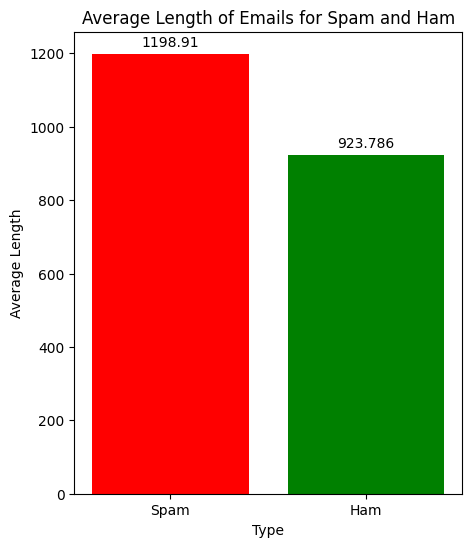

In [54]:
plt.figure(figsize=(5,6))
bar = plt.bar(['Spam', 'Ham'], [avg_spam, avg_ham], color=['Red', 'Green'])
plt.bar_label(bar, padding=3)

plt.title('Average Length of Emails for Spam and Ham')

plt.xlabel('Type')
plt.ylabel('Average Length')
plt.show()


Note that the length of spam emails is longer than the length of ham emails.

In [55]:
df['words'] = df['emails'].str.split().str.len()

df.head()

/tmp/ipykernel_855/31440987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words'] = df['emails'].str.split().str.len()


,emails,result,length,words
0,subject enron methanol meter 988291\r\nthis...,0,312,53
1,subject hpl nom for january 9 2001\r\n see at...,0,89,16
2,subject neon retreat\r\nho ho ho we re aroun...,0,2442,469
3,subject photoshop windows office cheap mai...,1,409,44
4,subject re indian springs\r\nthis deal is to ...,0,329,64


In [56]:
avg_spam_words = df[ df['result'] == 1]['words'].mean()
avg_ham_words = df[ df['result'] == 0]['words'].mean()



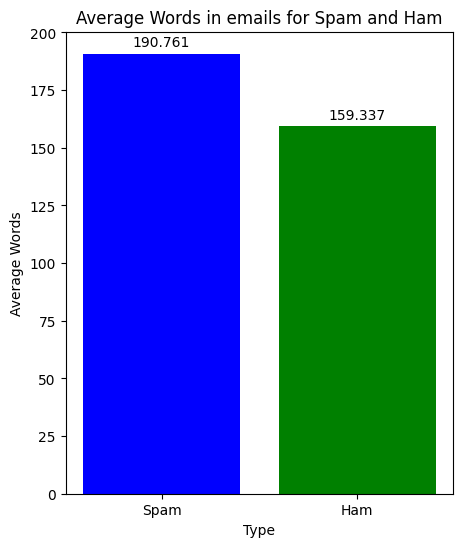

In [57]:
plt.figure(figsize=(5,6))
bar = plt.bar(['Spam', 'Ham'], [avg_spam_words, avg_ham_words], color=['Blue', 'Green'])
plt.bar_label(bar, padding=3)

plt.title('Average Words in emails for Spam and Ham')

plt.xlabel('Type')
plt.ylabel('Average Words')
plt.show()


In [58]:
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

In [59]:
custom_stopwords = set(STOPWORDS)

In [60]:
def generate_wordcloud(text, title, color):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        stopwords=custom_stopwords,
        colormap=color
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, pad=10)
    plt.axis('off')
    plt.show()


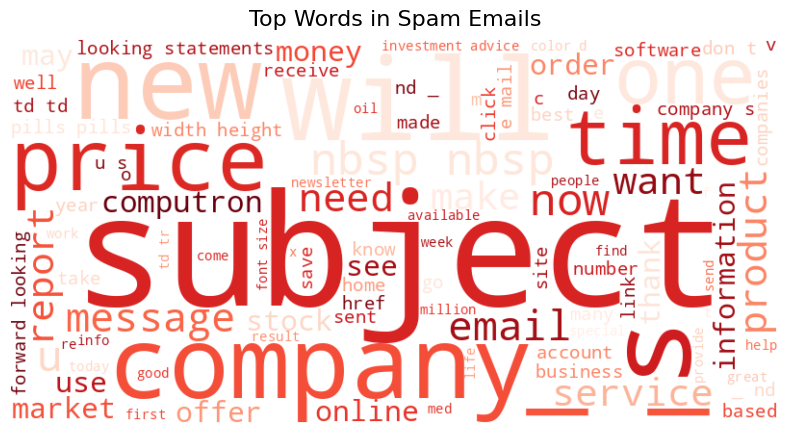

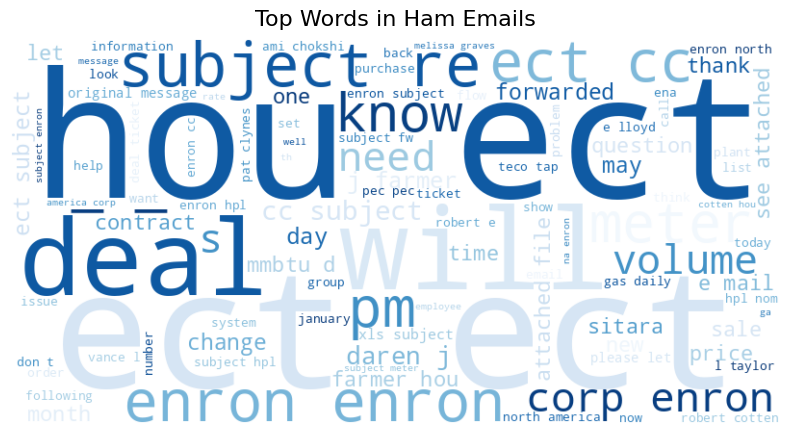

In [61]:
spam_emails = df[df['result'] == 1]['emails'].str.cat(sep=' ') #concat all emails into a single string.
ham_emails = df[df['result'] == 0]['emails'].str.cat(sep=' ')


generate_wordcloud(spam_emails, 'Top Words in Spam Emails', 'Reds')
generate_wordcloud(ham_emails, 'Top Words in Ham Emails', 'Blues')


In [62]:
from itertools import chain

spam = df[df['result']==1]['emails']
ham = df[df['result']==0]['emails']

spam_all = list(chain.from_iterable(spam))
ham_all = list(chain.from_iterable(ham))



## Data Pre-processing

In [63]:
pattern = r'\s+[a-zA-Z]\s+' #remove single characters.
pattern2 = r'\s+', ' ' #remove extra spaces

df['emails'] = df['emails'].str.replace(pattern, ' ',regex=True)
df['emails'] = df['emails'].str.replace(pattern, ' ',regex=True)



/tmp/ipykernel_855/2341807188.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emails'] = df['emails'].str.replace(pattern, ' ',regex=True)
/tmp/ipykernel_855/2341807188.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emails'] = df['emails'].str.replace(pattern, ' ',regex=True)


In [64]:
df.head()

,emails,result,length,words
0,subject enron methanol meter 988291\r\nthis...,0,312,53
1,subject hpl nom for january 9 2001\r\n see at...,0,89,16
2,subject neon retreat\r\nho ho ho we re aroun...,0,2442,469
3,subject photoshop windows office cheap mai...,1,409,44
4,subject re indian springs\r\nthis deal is to ...,0,329,64


In [65]:
#remove stopwords
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [66]:
stop_words = set(stopwords.words('english')) #set enables faster lookup

df['cleaned_emails'] = df['emails'].apply(
   lambda x: [word for word in word_tokenize(x) if word.lower() not in stop_words]
)

df.head()

/tmp/ipykernel_855/2635592193.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_emails'] = df['emails'].apply(


,emails,result,length,words,cleaned_emails
0,subject enron methanol meter 988291\r\nthis...,0,312,53,"[subject, enron, methanol, meter, 988291, foll..."
1,subject hpl nom for january 9 2001\r\n see at...,0,89,16,"[subject, hpl, nom, january, 9, 2001, see, att..."
2,subject neon retreat\r\nho ho ho we re aroun...,0,2442,469,"[subject, neon, retreat, ho, ho, ho, around, w..."
3,subject photoshop windows office cheap mai...,1,409,44,"[subject, photoshop, windows, office, cheap, m..."
4,subject re indian springs\r\nthis deal is to ...,0,329,64,"[subject, indian, springs, deal, book, teco, p..."


In [73]:
#stemming - basically reduce words to their base

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
df['cleaned_emails'] = df['cleaned_emails'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)
df['cleaned_emails'] = df['cleaned_emails'].apply(lambda x: ' '.join(x))


df.head()

/tmp/ipykernel_855/4101455148.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_emails'] = df['cleaned_emails'].apply(
/tmp/ipykernel_855/4101455148.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_emails'] = df['cleaned_emails'].apply(lambda x: ' '.join(x))


,emails,result,length,words,cleaned_emails
0,subject enron methanol meter 988291\r\nthis...,0,312,53,subject enron methanol meter 988291 follow not...
1,subject hpl nom for january 9 2001\r\n see at...,0,89,16,subject hpl nom januari 9 2001 see attach file...
2,subject neon retreat\r\nho ho ho we re aroun...,0,2442,469,subject neon retreat ho ho ho around wonder ti...
3,subject photoshop windows office cheap mai...,1,409,44,subject photoshop window offic cheap main tren...
4,subject re indian springs\r\nthis deal is to ...,0,329,64,subject indian spring deal book teco pvr reven...


## Machine Learning

In [74]:
#tf-idf vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfifd = TfidfVectorizer(max_features=2500,min_df=5, max_df=0.7, stop_words=stopwords.words('english'))
X = tfifd.fit_transform(df['cleaned_emails']).toarray()
y = df['result']


In [83]:
#use train_test_split function
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
#Run the model
from sklearn.naive_bayes import MultinomialNB

spam = MultinomialNB()
spam.fit(X_train, y_train)


MultinomialNB()

In [86]:
y_pred = spam.predict(X_test)

In [88]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score


In [89]:
cf= confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)


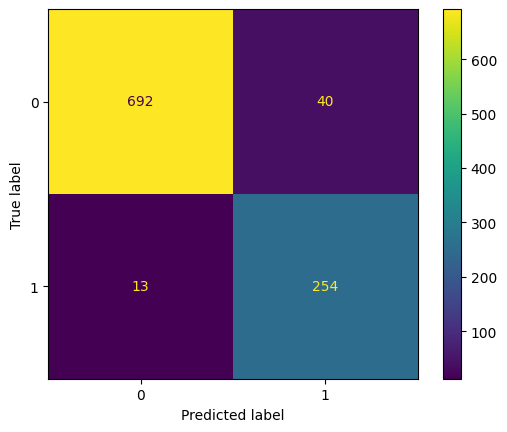

In [92]:
display = ConfusionMatrixDisplay(cf)
display.plot()
plt.show()


In [94]:
print(class_report)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       732
           1       0.86      0.95      0.91       267

    accuracy                           0.95       999
   macro avg       0.92      0.95      0.93       999
weighted avg       0.95      0.95      0.95       999



In [120]:
print(accuracy)

0.9469469469469469


* The model has an accuracy of 94%

